# 04 — Baseline Models (Logistic Regression + Random Forest)

Simple reference bar and a **fast fitness model** for GA/PSO. Not a multi-model tournament.

In [1]:
from pathlib import Path
import random

import numpy as np

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in [cwd, *cwd.parents] if (p / "environment.yml").exists()),
    cwd,
)

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

for d in (DATA_INTERIM, DATA_PROCESSED, FIGURES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Random seed  : {RANDOM_SEED}")

Project root : C:\Users\ishan\OneDrive\Documents\Work\3 Year 2 Semester\IT41033 - Nature Inspired Algorithms\Mini Project\ecommerce-customer-churn-prediction
Random seed  : 42


In [2]:
import json
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
)

X_train = pd.read_csv(DATA_PROCESSED / "X_train.csv")
X_test = pd.read_csv(DATA_PROCESSED / "X_test.csv")
y_train = pd.read_csv(DATA_PROCESSED / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_PROCESSED / "y_test.csv").squeeze()
feature_names = list(X_train.columns)
print(X_train.shape, y_train.mean())

(4504, 33) 0.16829484902309058


In [3]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "model": name,
        "accuracy": float(accuracy_score(y_te, pred)),
        "precision": float(precision_score(y_te, pred, zero_division=0)),
        "recall": float(recall_score(y_te, pred, zero_division=0)),
        "f1": float(f1_score(y_te, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_te, proba)),
        "pr_auc": float(average_precision_score(y_te, proba)),
        "train_time_sec": float(train_time),
    }
    cm = confusion_matrix(y_te, pred)
    return metrics, cm, proba, pred, model

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
rf = RandomForestClassifier(
    n_estimators=100, max_depth=8, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
)

results = []
artifacts = {}
for name, clf in [("LogisticRegression", lr), ("RandomForest", rf)]:
    metrics, cm, proba, pred, fitted = evaluate(name, clf, X_train, y_train, X_test, y_test)
    results.append(metrics)
    artifacts[name] = {"cm": cm, "proba": proba, "pred": pred, "model": fitted}
    print(name, metrics)

res_df = pd.DataFrame(results)
res_df.to_json(REPORTS_DIR / "04_baseline_metrics.json", orient="records", indent=2)
res_df

LogisticRegression {'model': 'LogisticRegression', 'accuracy': 0.7886323268206039, 'precision': 0.43513513513513513, 'recall': 0.8473684210526315, 'f1': 0.575, 'roc_auc': 0.886459739091318, 'pr_auc': 0.6723826911560253, 'train_time_sec': 0.043326400002115406}
RandomForest {'model': 'RandomForest', 'accuracy': 0.8916518650088809, 'precision': 0.6349206349206349, 'recall': 0.8421052631578947, 'f1': 0.7239819004524887, 'roc_auc': 0.9525472334682861, 'pr_auc': 0.8263054642683844, 'train_time_sec': 0.20560090000071796}


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time_sec
0,LogisticRegression,0.788632,0.435135,0.847368,0.575000,0.886460,0.672383,0.043326
1,RandomForest,0.891652,0.634921,0.842105,0.723982,0.952547,0.826305,0.205601


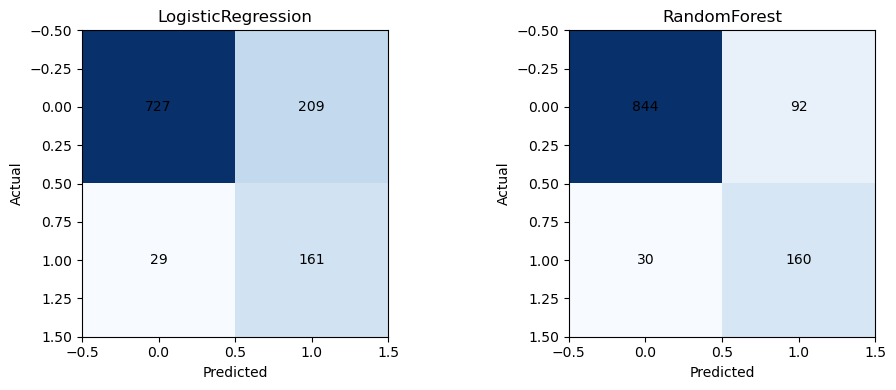

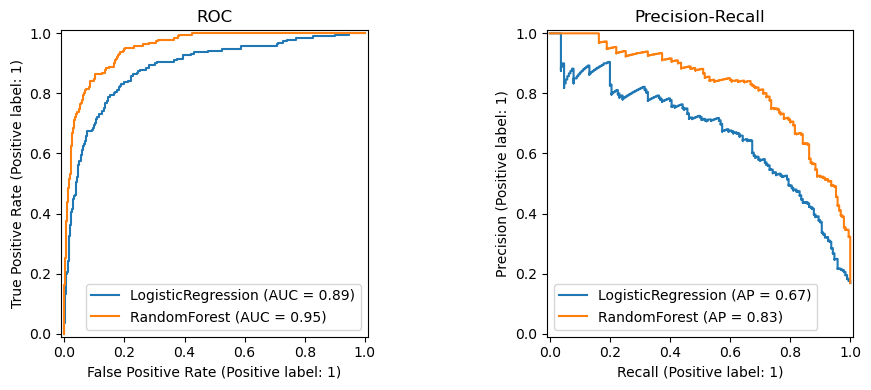

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["LogisticRegression", "RandomForest"]):
    cm = artifacts[name]["cm"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_confusion_matrices.png", dpi=150)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name in ["LogisticRegression", "RandomForest"]:
    RocCurveDisplay.from_predictions(y_test, artifacts[name]["proba"], name=name, ax=ax[0])
    PrecisionRecallDisplay.from_predictions(y_test, artifacts[name]["proba"], name=name, ax=ax[1])
ax[0].set_title("ROC")
ax[1].set_title("Precision-Recall")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_roc_pr.png", dpi=150)
plt.show()

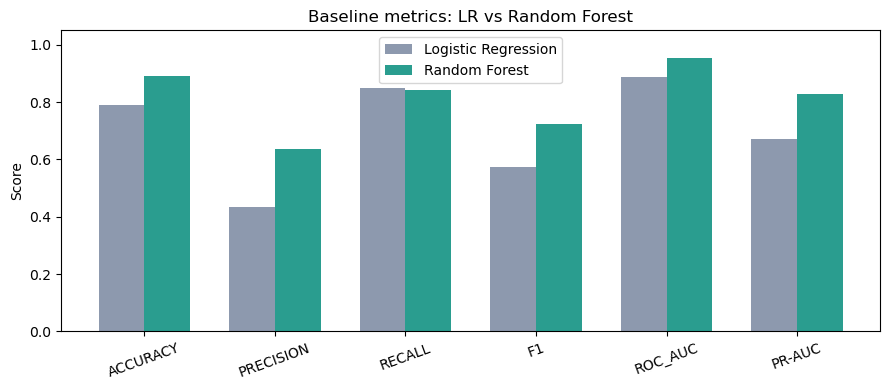

In [5]:
# Visual: side-by-side metrics (easy comparison)
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
plot_df = res_df.set_index("model")[metric_cols]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metric_cols))
w = 0.35
ax.bar(x - w / 2, plot_df.loc["LogisticRegression"], width=w, label="Logistic Regression", color="#8d99ae")
ax.bar(x + w / 2, plot_df.loc["RandomForest"], width=w, label="Random Forest", color="#2a9d8f")
ax.set_xticks(x)
ax.set_xticklabels([m.upper() if m != "pr_auc" else "PR-AUC" for m in metric_cols], rotation=20)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Baseline metrics: LR vs Random Forest")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_metric_comparison.png", dpi=150)
plt.show()

**Insight (simple):** Look mainly at **Recall**, **F1**, and **PR-AUC**. The stronger model here becomes the **fitness model** inside GA and PSO (usually Random Forest).

## Fitness-model decision

We select the stronger baseline on **F1** and **PR-AUC** (primary). Random Forest is the default HHO/GA/PSO fitness model when competitive, because it is nonlinear, fast enough for repeated CV, and stable with `class_weight='balanced'`.

In [6]:
# Choose fitness model
best = res_df.sort_values(["f1", "pr_auc"], ascending=False).iloc[0]
fitness_name = best["model"]
print("Selected fitness / reference model:", fitness_name)
print(best)

joblib.dump(artifacts["RandomForest"]["model"], MODELS_DIR / "rf_baseline.joblib")
joblib.dump(artifacts["LogisticRegression"]["model"], MODELS_DIR / "lr_baseline.joblib")

choice = {
    "fitness_model": fitness_name,
    "reason": "Higher F1 then PR-AUC on held-out test among LR and small RF",
    "metrics": results,
}
(DATA_PROCESSED / "04_fitness_model_choice.json").write_text(json.dumps(choice, indent=2), encoding="utf-8")
choice

Selected fitness / reference model: RandomForest
model             RandomForest
accuracy              0.891652
precision             0.634921
recall                0.842105
f1                    0.723982
roc_auc               0.952547
pr_auc                0.826305
train_time_sec        0.205601
Name: 1, dtype: object


{'fitness_model': 'RandomForest',
 'reason': 'Higher F1 then PR-AUC on held-out test among LR and small RF',
 'metrics': [{'model': 'LogisticRegression',
   'accuracy': 0.7886323268206039,
   'precision': 0.43513513513513513,
   'recall': 0.8473684210526315,
   'f1': 0.575,
   'roc_auc': 0.886459739091318,
   'pr_auc': 0.6723826911560253,
   'train_time_sec': 0.043326400002115406},
  {'model': 'RandomForest',
   'accuracy': 0.8916518650088809,
   'precision': 0.6349206349206349,
   'recall': 0.8421052631578947,
   'f1': 0.7239819004524887,
   'roc_auc': 0.9525472334682861,
   'pr_auc': 0.8263054642683844,
   'train_time_sec': 0.20560090000071796}]}